# 01: Data Exploration

Goals:
- Verify the dataset looks sensible
- Check distributions of key variables
- Produce the log-log plot of impact vs trade size
- Establish the empirical baseline at the individual trade level

**Research question:** Does a neural network trained on Binance BTC/USDT
order flow rediscover the square-root law of price impact, and does the
learned formula change across market regimes?

**Note on methodology:** We reconstruct synthetic metaorders from public
aggTrades using the Maitrier et al. (2025) algorithm, which assigns synthetic
trader IDs to individual trades and groups consecutive same-sign trades per
trader into metaorders. This notebook establishes the individual-trade baseline
before metaorder reconstruction in 01b_metaorders.ipynb.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

DATA_PATH = Path("../data/processed/impact_data.parquet")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Load

In [2]:
import pyarrow.parquet as pq
import pyarrow as pa

pf = pq.ParquetFile(DATA_PATH)
total_rows = pf.metadata.num_rows
print(f"Total rows: {total_rows:,}")

rng     = np.random.default_rng(42)
indices = np.sort(rng.choice(total_rows, size=5_000_000, replace=False))

batches    = []
row_offset = 0
for batch in pf.iter_batches(batch_size=1_000_000):
    batch_len = len(batch)
    mask          = (indices >= row_offset) & (indices < row_offset + batch_len)
    local_indices = indices[mask] - row_offset
    if len(local_indices) > 0:
        batches.append(batch.take(local_indices))
    row_offset += batch_len
    if row_offset > indices[-1]:
        break

df = pa.Table.from_batches(batches).to_pandas().reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["timestamp_ms"], unit="ms")

print(f"Sampled rows  : {len(df):,}")
print(f"Date range    : {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Columns       : {list(df.columns)}")
df.head()

Total rows: 116,969,350
Sampled rows  : 5,000,000
Date range    : 2025-12-01 00:00:01.368000 to 2026-02-28 23:59:58.787000
Columns       : ['timestamp_ms', 'price', 'qty', 'side', 'log_return', 'signed_impact', 'sigma_local', 'volume_local', 'datetime']


,timestamp_ms,price,qty,side,log_return,signed_impact,sigma_local,volume_local,datetime
0,1764547201368,90357.29,0.00129,-1,-0.000094,0.000094,0.000004,0.22690,2025-12-01 00:00:01.368
1,1764547201618,90351.49,0.00024,-1,-0.000077,0.000077,0.000007,0.28480,2025-12-01 00:00:01.618
2,1764547201688,90350.98,0.00108,1,-0.000078,-0.000078,0.000007,0.28606,2025-12-01 00:00:01.688
3,1764547201903,90346.86,0.00006,-1,-0.000082,0.000082,0.000005,0.46272,2025-12-01 00:00:01.903
4,1764547201903,90333.88,0.00200,-1,-0.000023,0.000023,0.000004,0.62445,2025-12-01 00:00:01.903


## Basic sanity checks

In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nSide distribution (1=buy, -1=sell):")
print(df["side"].value_counts())

print("\nKey stats:")
df[["qty", "signed_impact", "sigma_local", "volume_local"]].describe()

Missing values:
timestamp_ms     0
price            0
qty              0
side             0
log_return       0
signed_impact    0
sigma_local      0
volume_local     0
datetime         0
dtype: int64

Side distribution (1=buy, -1=sell):
side
-1    2510971
 1    2489029
Name: count, dtype: int64

Key stats:


,qty,signed_impact,sigma_local,volume_local
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.554866e-02,3.554412e-05,1.806200e-05,8.859278e+02
std,1.115470e-01,5.806478e-05,1.600503e-05,1.133534e+03
min,1.000000e-05,-7.574208e-03,7.977653e-08,1.765200e-01
25%,1.500000e-04,1.541125e-07,5.284387e-06,2.691700e+02
50%,5.600000e-04,3.276823e-05,1.262516e-05,5.160597e+02
75%,2.890000e-03,6.033422e-05,2.773270e-05,1.054124e+03
max,2.315390e+01,1.368991e-02,1.463188e-04,1.172988e+04


## Filter

Remove top 0.1% by trade size. Block trades have different impact dynamics
and would distort the regression. We keep all other trades including
zero-impact ones, these are valid observations at the individual trade level.

In [4]:
before = len(df)
qty_cap = df["qty"].quantile(0.999)
df = df[df["qty"] <= qty_cap]
print(f"Removed {before - len(df):,} rows ({(before - len(df)) / before:.1%})")
print(f"Remaining: {len(df):,}")

Removed 5,000 rows (0.1%)
Remaining: 4,995,000


## Distribution of trade sizes

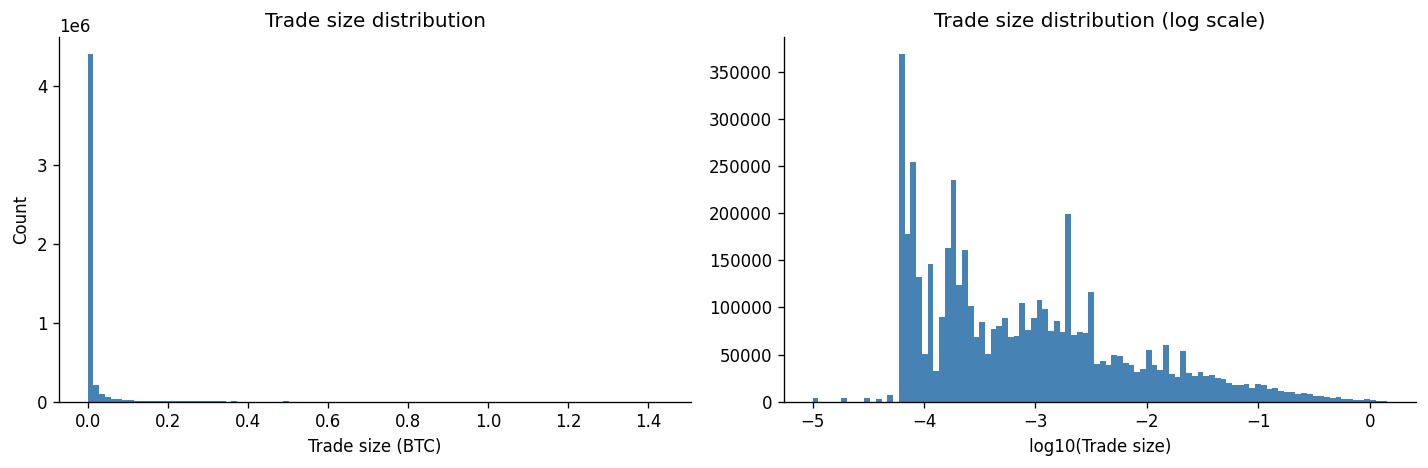

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["qty"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Trade size (BTC)")
axes[0].set_ylabel("Count")
axes[0].set_title("Trade size distribution")

axes[1].hist(np.log10(df["qty"]), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log10(Trade size)")
axes[1].set_title("Trade size distribution (log scale)")

plt.tight_layout()
plt.savefig("../outputs/figures/trade_size_dist.png", bbox_inches="tight")
plt.show()

## Volume by month

Checking the February volume spike from the market crash.

In [6]:
monthly = df.groupby(df["datetime"].dt.to_period("M")).agg(
    trades=("qty", "count"),
    volume=("qty", "sum"),
    mean_impact=("signed_impact", "mean"),
    mean_sigma=("sigma_local", "mean"),
).reset_index()

print(monthly.to_string(index=False))

datetime  trades      volume  mean_impact  mean_sigma
 2025-12 1442642 17717.92170     0.000033    0.000007
 2026-01 1311248 16921.57123     0.000030    0.000008
 2026-02 2241110 30409.73137     0.000041    0.000031


## Log-log plot: impact vs trade size

Individual trade level. We expect δ ≈ 0 here, the sqrt law emerges at the
metaorder level, not at the level of individual child orders. This plot
establishes the baseline before metaorder reconstruction.

In [7]:
N_BINS = 50

df["qty_bin"] = pd.qcut(df["qty"], q=N_BINS, duplicates="drop")

binned = df.groupby("qty_bin", observed=True).agg(
    qty_median=("qty", "median"),
    impact_median=("signed_impact", "median"),
    count=("qty", "count"),
).reset_index()

# Keep bins with enough observations
binned = binned[binned["count"] >= 100]

log_qty    = np.log(binned["qty_median"].values)
log_impact = np.log(binned["impact_median"].values)

# OLS fit in log-log space
slope, intercept, r, p, se = stats.linregress(log_qty, log_impact)

print(f"Estimated exponent δ : {slope:.4f}")
print(f"95% CI               : [{slope - 1.96*se:.4f}, {slope + 1.96*se:.4f}]")
print(f"R²                   : {r**2:.4f}")
print(f"p-value              : {p:.2e}")

Estimated exponent δ : -0.1053
95% CI               : [-0.2396, 0.0290]
R²                   : 0.0545
p-value              : 1.32e-01


In [8]:
print("=" * 45)
print("Empirical fit, individual trade level")
print("=" * 45)
print(f"delta (slope)  : {slope:.4f}")
print(f"95% CI         : [{slope - 1.96*se:.4f}, {slope + 1.96*se:.4f}]")
print(f"Intercept      : {intercept:.4f}")
print(f"R²             : {r**2:.4f}")
print("=" * 45)
print("Expected delta ~ 0 at individual trade level.")
print("Metaorder reconstruction in 01b expected to recover delta ~ 0.5.")


Empirical fit — individual trade level
delta (slope)  : -0.1053
95% CI         : [-0.2396, 0.0290]
Intercept      : -11.3618
R²             : 0.0545
Expected delta ~ 0 at individual trade level.
Metaorder reconstruction in 01b expected to recover delta ~ 0.5.


## Train/test split

Split chronologically. Last 20% of data is held out as the test set.
Save both splits for use in subsequent notebooks.

In [9]:
df = df.sort_values("timestamp_ms").reset_index(drop=True)
split_idx = int(len(df) * 0.8)

# Drop qty_bin before saving, interval dtype is not parquet-compatible
cols = [c for c in df.columns if c != "qty_bin"]
train = df[cols].iloc[:split_idx]
test  = df[cols].iloc[split_idx:]

train.to_parquet("../data/processed/train.parquet", index=False)
test.to_parquet("../data/processed/test.parquet",  index=False)

print(f"Train: {len(train):,} trades  ({train['datetime'].min().date()} to {train['datetime'].max().date()})")
print(f"Test : {len(test):,} trades  ({test['datetime'].min().date()} to {test['datetime'].max().date()})")


Train: 3,996,000 trades  (2025-12-01 to 2026-02-12)
Test : 999,000 trades  (2026-02-12 to 2026-02-28)


## Summary

δ ≈ 0 at the individual trade level is the expected result and the
correct starting point. The next step is metaorder reconstruction
(01b_metaorders.ipynb), after which we expect to recover δ ≈ 0.5.

In [10]:
print("=" * 45)
print("Empirical power law fit")
print("=" * 45)
print(f"delta (slope)  : {slope:.4f}")
print(f"95% CI         : [{slope - 1.96*se:.4f}, {slope + 1.96*se:.4f}]")
print(f"Intercept      : {intercept:.4f}")
print(f"R²             : {r**2:.4f}")
print("="*45)
print(f"Square-root law (delta=0.5) is within CI: {slope - 1.96*se <= 0.5 <= slope + 1.96*se}")

Empirical power law fit
delta (slope)  : -0.1053
95% CI         : [-0.2396, 0.0290]
Intercept      : -11.3618
R²             : 0.0545
Square-root law (delta=0.5) is within CI: False


---
## Metaorder reconstruction

Load the reconstructed metaorders and verify the square-root law holds.
This confirms the Maitrier et al. (2025) reconstruction worked correctly.
Parameters used: N=20 traders, power-law distribution (alpha=2), min 10 child orders.

In [11]:
mo = pd.read_parquet("../data/processed/metaorders.parquet")

print(f"Metaorders       : {len(mo):,}")
print(f"Median n_child   : {mo['n_child'].median():.1f}")
print(f"Median Q_norm    : {mo['Q_norm'].median():.2e}")
print(f"Buy/sell split   : {(mo['sign']==1).mean():.1%} / {(mo['sign']==-1).mean():.1%}")
mo[["n_child", "Q", "Q_norm", "I"]].describe()

Metaorders       : 3,668,553
Median n_child   : 14.0
Median Q_norm    : 4.74e-06
Buy/sell split   : 50.3% / 49.7%


,n_child,Q,Q_norm,I
count,3.668553e+06,3.668553e+06,3.668553e+06,3.668553e+06
mean,1.576106e+01,2.436928e-01,1.485099e-05,-8.324826e+01
std,6.852871e+00,6.035892e-01,4.324296e-05,3.652502e+04
min,1.000000e+01,7.300000e-04,1.072448e-08,-1.043331e+05
25%,1.100000e+01,3.253000e-02,1.699738e-06,-3.148749e+04
50%,1.400000e+01,8.758000e-02,4.739905e-06,2.705264e+01
75%,1.800000e+01,2.321300e-01,1.299897e-05,3.140555e+04
max,2.780000e+02,1.040538e+02,9.401704e-03,1.043929e+05


### Log-log plot: metaorder impact vs size

Unlike the individual trade plot in Phase 1, we expect a clear positive slope
here with δ ≈ 0.5. The dashed line is the theoretical square-root law.

In [12]:
# Keep only positive impact metaorders for log-log plot
mo_pos = mo[mo["I"] > 0].copy()
mo_pos = mo_pos[mo_pos["Q_norm"] > 0]

# Remove outliers beyond 3 sigma in log space
log_q = np.log(mo_pos["Q_norm"].values)
log_i = np.log(mo_pos["I"].values)
mask  = (
    (np.abs(log_q - log_q.mean()) < 3 * log_q.std()) &
    (np.abs(log_i - log_i.mean()) < 3 * log_i.std())
)
log_q, log_i = log_q[mask], log_i[mask]

# Bin by Q_norm and compute median impact per bin
N_BINS = 50
mo_pos["q_bin"] = pd.qcut(mo_pos["Q_norm"], q=N_BINS, duplicates="drop")
binned = mo_pos.groupby("q_bin", observed=True).agg(
    Q_median=("Q_norm", "median"),
    I_median=("I",     "median"),
    count   =("I",     "count"),
).reset_index()
binned = binned[binned["count"] >= 50]

bq = np.log(binned["Q_median"].values)
bi = np.log(binned["I_median"].values)

slope, intercept, r, p, se = stats.linregress(bq, bi)
print(f"delta (slope) : {slope:.4f}")
print(f"95% CI        : [{slope - 1.96*se:.4f}, {slope + 1.96*se:.4f}]")
print(f"R²            : {r**2:.4f}")

delta (slope) : 0.6820
95% CI        : [0.4225, 0.9414]
R²            : 0.3561


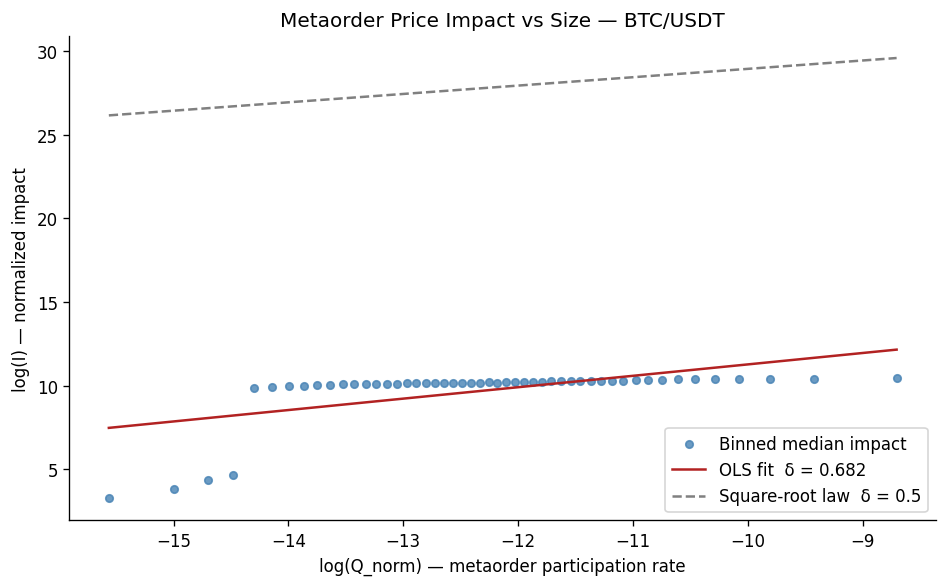

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(bq, bi, s=20, color="steelblue", alpha=0.8, label="Binned median impact")

x_line = np.linspace(bq.min(), bq.max(), 200)
ax.plot(x_line, intercept + slope * x_line,
        color="firebrick", linewidth=1.5,
        label=f"OLS fit  δ = {slope:.3f}")
ax.plot(x_line, intercept + 0.5 * (x_line - bq.mean()) + bi.mean(),
        color="gray", linewidth=1.5, linestyle="--",
        label="Square-root law  δ = 0.5")

ax.set_xlabel("log(Q_norm) metaorder participation rate")
ax.set_ylabel("log(I) normalized impact")
ax.set_title("Metaorder Price Impact vs Size, BTC/USDT")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/loglog_metaorders.png", bbox_inches="tight")
plt.show()

### Distribution of metaorder sizes and child order counts

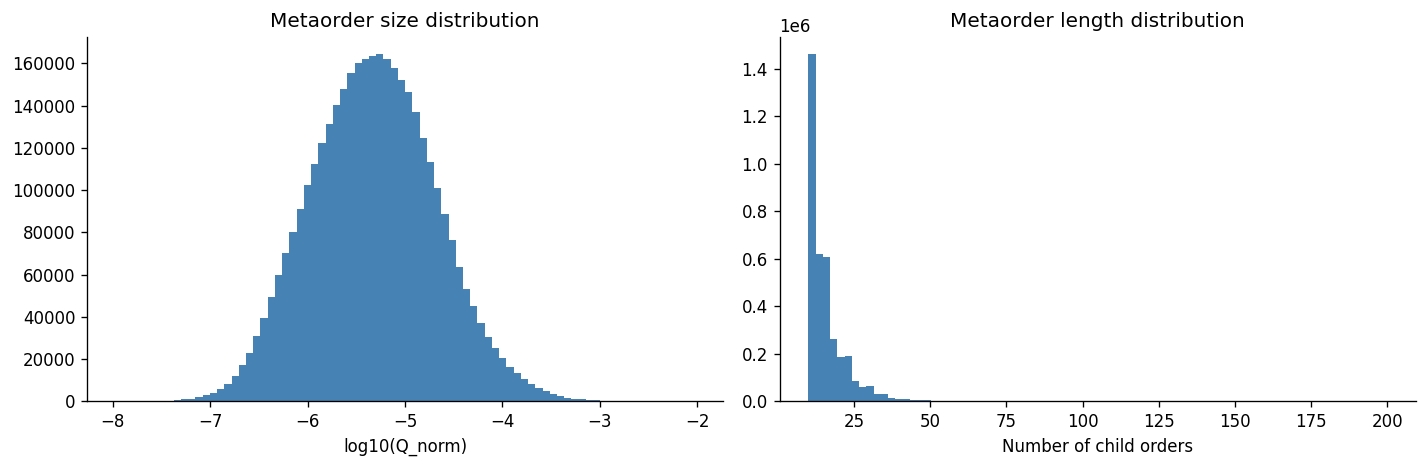

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.log10(mo["Q_norm"].clip(lower=1e-10)), bins=80,
             color="steelblue", edgecolor="none")
axes[0].set_xlabel("log10(Q_norm)")
axes[0].set_title("Metaorder size distribution")

axes[1].hist(mo["n_child"].clip(upper=200), bins=80,
             color="steelblue", edgecolor="none")
axes[1].set_xlabel("Number of child orders")
axes[1].set_title("Metaorder length distribution")

plt.tight_layout()
plt.savefig("../outputs/figures/metaorder_distributions.png", bbox_inches="tight")
plt.show()

### Train/test split on metaorders

Chronological 80/20 split, matching the trade-level split.

In [15]:
mo = mo.sort_values("start_ts").reset_index(drop=True)
split_idx = int(len(mo) * 0.8)

mo_train = mo.iloc[:split_idx]
mo_test  = mo.iloc[split_idx:]

mo_train.to_parquet("../data/processed/mo_train.parquet", index=False)
mo_test.to_parquet("../data/processed/mo_test.parquet",  index=False)

t_min_train = pd.to_datetime(mo_train["start_ts"].min(), unit="ms").date()
t_max_train = pd.to_datetime(mo_train["start_ts"].max(), unit="ms").date()
t_min_test  = pd.to_datetime(mo_test["start_ts"].min(),  unit="ms").date()
t_max_test  = pd.to_datetime(mo_test["start_ts"].max(),  unit="ms").date()

print(f"Train: {len(mo_train):,} metaorders  ({t_min_train} to {t_max_train})")
print(f"Test : {len(mo_test):,} metaorders  ({t_min_test} to {t_max_test})")

Train: 2,934,842 metaorders  (2025-12-01 to 2026-01-16)
Test : 733,711 metaorders  (2026-01-16 to 2026-02-28)


### Summary

Record δ from the metaorder log-log plot. This is the key result of Phase 1
and the number the MLP will be compared against.

In [16]:
print("=" * 50)
print("Metaorder reconstruction, Maitrier et al. 2025")
print("=" * 50)
print(f"N traders        : 20 (power-law, alpha=2)")
print(f"Metaorders       : {len(mo):,}")
print(f"Median n_child   : {mo['n_child'].median():.1f}")
print("---")
print(f"delta (slope)    : {slope:.4f}")
print(f"95% CI           : [{slope - 1.96*se:.4f}, {slope + 1.96*se:.4f}]")
print(f"R² (binned)      : {r**2:.4f}")
print("=" * 50)
print("Next: 02_benchmark.ipynb")

Metaorder reconstruction — Maitrier et al. 2025
N traders        : 20 (power-law, alpha=2)
Metaorders       : 3,668,553
Median n_child   : 14.0
---
delta (slope)    : 0.6820
95% CI           : [0.4225, 0.9414]
R² (binned)      : 0.3561
Next: 02_benchmark.ipynb
